# Introduction to Linear Algebra
## Matrices, Vectors, and Dot Products


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
from mpl_toolkits.mplot3d import Axes3D

## Learning outcomes

- Understand how and why linear algebra is useful for **analyzing data**
- Learn how to think about **high-dimensional vectors** and their geometry
- Learn how to perform elementary linear algebra operations with `numpy`

**Note**: this learning unit contains mostly mathematical theory, along with practical examples for elementary linear algebra computations with `numpy`.

## What is linear algebra?

Linear algebra is a set of mathematical tools that give us techiques to manipulate groups of numbers simultaneously. It is in essence the study of techniques for manipulating and characterizing **vectors** and **matrices**.

### What is a vector?
> An $M$-dimensional **vector** is a collection of $M$ numbers 

$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_M \end{bmatrix} $$



### What is a matrix?
An $M \times N$ array of numbers

$$\mathbf{A} = \begin{bmatrix} A_{11} & A_{12} & \ldots & A_{1N} \\ A_{21} & A_{22} & \ldots & A_{2N} \\ \vdots & \vdots & \vdots & \vdots \\ A_{M1} & A_{M2} & \ldots & A_{MN} \end{bmatrix}$$

- $M$ is the number of rows, $N$ is the number of columns
- $A_{ij}$ is the element of the matrix $\mathbf{A}$ in the $i$th row and $j$th column

In [2]:
# Here we are defining two vectors algebraically 

u = np.array([1,2])
v = np.array([-2,3])

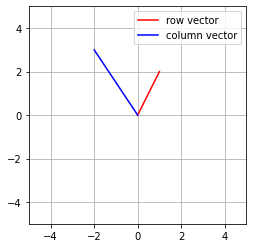

In [3]:
# Visualising vectors in 2D - an alternate definition of vectors is as a directed line segment

plt.plot([0,u[0]],[0,u[1]],'r',label='row vector')

plt.plot([0,v[0]],[0,v[1]],'b',label='column vector')

plt.axis('square')
plt.axis ([-5,5,-5,5])
plt.grid()
plt.legend()

### Visualising vectors in 3D


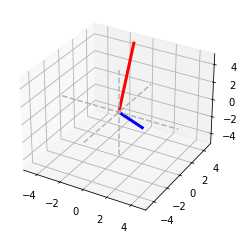

In [4]:

v = np.array([2, 0, -1])
w = np.array([-1, 4, 5])

fig = plt.figure(figsize=plt.figaspect(1))
ax = fig.add_subplot(111, projection='3d')

ax.plot([0,v[0]],[0,v[1]],[0,v[2]],'b',linewidth=3)
ax.plot([0,w[0]],[0,w[1]],[0,w[2]],'r',linewidth=3)

ax.plot([-5,5],[0,0],[0,0],'--',color=[.7,.7,.7])
ax.plot([0,0],[-5,5],[0,0],'--',color=[.7,.7,.7])
ax.plot([0,0],[0,0],[-5,5],'--',color=[.7,.7,.7])

ax.set_xlim3d(-5,5)
ax.set_ylim3d(-5,5)
ax.set_zlim3d(-5,5)

plt.show()

### Applications

The numerical data you work with on a daily basis is just a collection of vectors and matrices.

Linear algebra has many applications in the field of data science and its laws form the basis of machine learning. It's so useful to us because it turns complicated problems into efficiently calculated problems.

In the Introduction to Machine Learning module you will study linear regression. Linear regression calculations are performed by Python via turning data into a system of equations represented by vectors. This allows Python to solve the regression calculation to find the equation for the line of best fit efficiently.

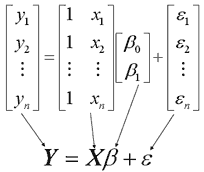





So understanding a bit of the maths behind linear algebra will give you an insight into how algorithms work behind the scenes in Python.

In addition visualisations of data as vectors in 2D & 3D can help to provide insights into data.

**Example:** heights and weights of various athletes can be seen as a collection of two-dimensional vectors containing the height and weight of each athlete

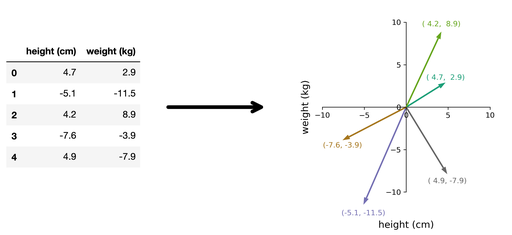

# Manipulating vectors

Just as we can add, subtract, multiply and divide numbers, the same operations can be performed on **vectors** using the laws of linear algebra. 

<div class="grid-layout-1-3"><div class="grid-item center"><h3><strong>Scalar multiplication</strong></h3>
    
<p>$$\mathbf{u} = a\mathbf{v}$$
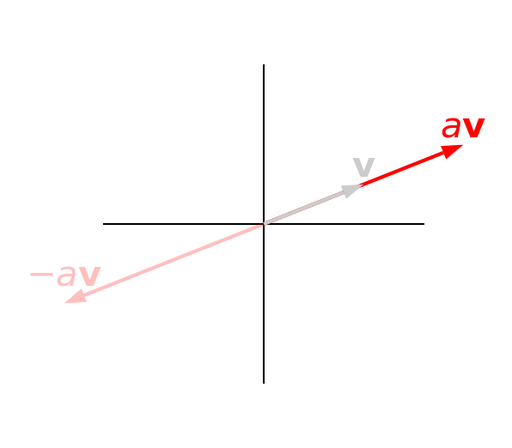</p>
</div><div class="grid-item center"><h3><strong>Vector addition</strong></h3>
<p>$$\mathbf{u} = \mathbf{v} + \mathbf{w}$$
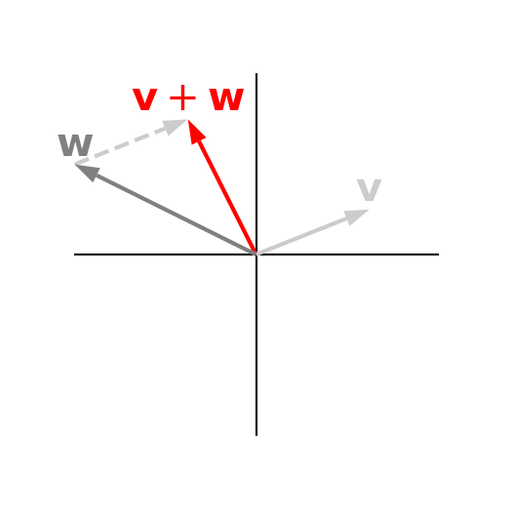</p>
</div><div class="grid-item center"><h3><strong>Linear combination</strong></h3>
<p>$$\mathbf{u} = a\mathbf{v} + b\mathbf{w}$$
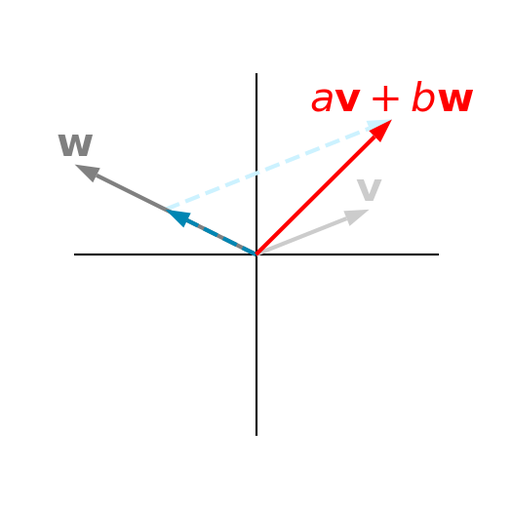</p>
</div></div><div class="grid-layout-footnote"></div>

Linear algebra helps us to achieve greater speed and efficiency when performing operations on arrays of data.

We will demonstrate below with a simple example of multiplying two arrays, and calculating the processing speed using linear algebra vs. manually.

In [5]:
# Multiply two arrays 

import time
start = time.process_time()

x = [1,2,3]
y = [2,3,4]
product = []
for i in range(len(x)):
    product.append(x[i]*y[i])
    
print(time.process_time() - start)

0.0029804580000014624


In [6]:
# Linear algebra version

start = time.process_time()

x = np.array([1,2,3])
y = np.array([2,3,4])
x * y

print(time.process_time() - start)

0.0036133760000005566


# Characterizing vectors

<div class="grid-layout-1-2"><div class="grid-item left"><h2><strong>Vector norm</strong></h2>
</div><div class="grid-item left"><h4>How "big" is a vector?</h4>
</div></div><div class="grid-layout-footnote"></div>

<div class="grid-layout-1-2"><div class="grid-item left"><ul>
<li><strong>$L^2$ norm</strong>: use Pythagoras theorem!
$$||\mathbf{v}||_2 = \sqrt{v_1^2 + v_2^2 + \ldots + v_M^2}$$</li>
<li><strong>$L^1$ norm</strong>: how many "blocks" do you have to travel? (the "Manhattan norm")
$$||\mathbf{v}||_1 = |v_1| + |v_2| + \ldots + |v_M|$$</li>
<li><strong>$L^\infty$ norm</strong>: largest element of the vector
$$||\mathbf{v}||_\infty = \max { |v_1|, |v_2|, \ldots, |v_M| } $$</li>
</ul>
</div><div class="grid-item left"><p>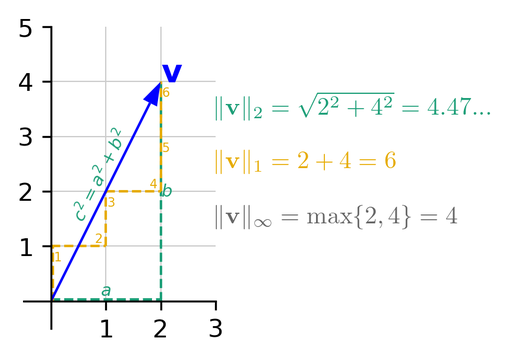</p>
</div></div><div class="grid-layout-footnote"></div>

A simple property of a vector that we might want to know is how "big" it is. But it's not really obvious how to quantify this -- what does it mean for a collection of numbers to be "big"?

For example, we might say that a collection of $M$ numbers is "big" if
* when plotted as a point on $M$ axes, this point is far away from the origin
* the $M$ numbers are all far from 0 -- that is, their absolute values are large
* one of the $M$ numbers is very far from 0

While there is no single true answer to this question, linear algebra provides us with a systematic way for deriving different answers, via what is called a **vector norm**. 

### Applications

In machine learning, vector norms are often used to ensure that vectors of parameters don't get too "big" when being optimized. Of course, the solutions that these algorithms will find will depend on what you mean by "big" -- that is, which vector norm is used. Typically, the $L^1$ or $L^2$ norms are used, or a combination thereof.

### Vector norms in `numpy`
- use `linalg.norm()` function
- pick which norm using `ord` argument

In [7]:
v = np.random.randn(2)                     # a random 2D vector
norm_L1 = np.linalg.norm(v, ord=1)         # calculate L1 norm
norm_L2 = np.linalg.norm(v, ord=2)         # calculate L2 norm
norm_Linf = np.linalg.norm(v, ord=np.inf)  # calculate L-infinity norm

print(norm_L1)
print(norm_L2)
print(norm_Linf)

1.2255213357480361
0.9553832856622354
0.8971951509592649


## Dot product

The dot product is perhaps the **most important operation** in all of linear algebra.

Each corresponding pair of elements between two vectors is multiplied together and then the results are added up into one single number.

We can explain this calculation using mathematical symbols:

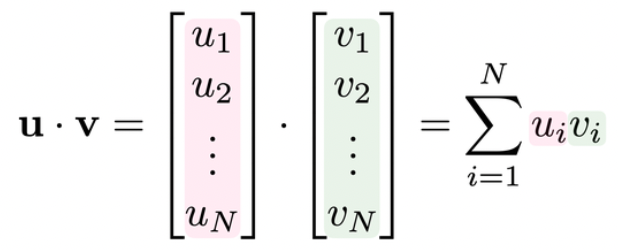

### Applications

The dot product can be used as a way of measuring the "overlap" between two vectors. In this way, it can be used to indicate how **similar** a pair of vectors are to one another.

In addition, there is an important application of the dot product in statistics! If we have two columns of data (we can think of these as vectors), the correlation coefficient between the two variables involves the dot product of the vectors.

In [10]:
v = np.arange(10,22,3)
w = np.arange(5,15,3)

# Working out the dot product using the numpy function
dp1 = np.dot(v,w)

# Can you write a for loop to calculate the dot product without the numpy function?

0.60530206024143
0.60530206024143


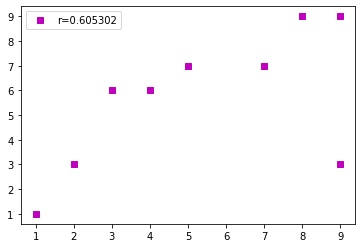

In [9]:
# Are these two variables correlated?

Hours_spent_studying_linear_algebra = np.array([4,5,8,2,9,9,1,3,7])

Life_happiness = np.array([6,7,9,3,9,3,1,6,7])

# First we would subtract the means

h = Hours_spent_studying_linear_algebra - np.mean(Hours_spent_studying_linear_algebra)
l = Life_happiness - np.mean(Life_happiness)

# compute the correlation

numer = np.dot(h,l)
denom = np.sqrt(np.dot(h,h))*np.sqrt(np.dot(l,l))

r1 = numer/denom

r2 = np.corrcoef(h,l)[1][0]

print(r1)
print(r2)

# never trust a number alone, let's plot a graph and see if it makes sense
plt.plot(Hours_spent_studying_linear_algebra,Life_happiness,'ms',label='r=%g' %r1)
plt.legend()

## Summary

You should now:

- know that we can represent rows and columns of data as vectors, and grids of data as matrices
- understand the importance of linear algebra in underpinning manipulation of data "behind the scenes" in Python
- know how to define the magnitude of a vector
- know how to calculate the dot product of two vectors